### Phase 2 (Data Understanding)

After deepening the understanding of business requirement, we decided to discover how data is processed tbrough implementing code due to the overload of large size dataset. There are 5 stages in this phase:

* Collect and load the data

* Explore the data (distributions, correlations, outliers, etc.) and Check data quality (missing, duplicates, consistency)

* Visualization and Data Desciption Report

### Variables' definition

A short description of the variables of the dataset.

vin: Vehicle Identification Number is a unique encoded string for every vehicle. A vehicle identification number (VIN) (also called a chassis number or frame number) is a unique code, including a serial number, used by the automotive industry to identify individual motor vehicles, towed vehicles, motorcycles, scooters and mopeds, as defined in ISO 3779 (content and structure) and ISO 4030 (location and attachment).

back_legroom: Legroom in the rear seat measured in inches.

bed: Category of bed size (open cargo area) in pickup truck. Null usually means the vehicle isn't a pickup truck.

bed_height: Height of bed in inches.

bed_length: Length of bed in inches.

body_type: Body Type of the vehicle. Like Convertible, Hatchback, Sedan, etc.

cabin: Category of cabin size (open cargo area) in pickup truck. Eg: Crew Cab, Extended Cab, etc.

city: City where the car is listed. Eg: Houston, San Antonio, etc.

city_fuel_economy: Fuel economy in city traffic in km per litre.

combine_fuel_economy: Combined fuel economy is a weighted average of City and Highway fuel economy in km per litre.

daysonmarket: Days since the vehicle was first listed on the website.

dealer_zip: Zipcode of the dealer.

description: Vehicle description on the vehicle's listing page.

engine_cylinders: The engine configuration. Eg: I4, V6, etc.

engine_displacement: Engine displacement is the measure of the cylinder volume swept by all of the pistons of a piston engine, excluding the combustion chambers.

engine_type: The engine configuration. Eg: I4, V6, etc.

exterior_color: Exterior color of the vehicle, usually a fancy one same as the brochure.

fleet: Whether the vehicle was previously part of a fleet.

frame_damaged: Whether the vehicle has a damaged frame.

franchise_dealer: Whether the dealer is a franchise dealer.

franchise_make: The company that owns the franchise.

front_legroom: The legroom in inches for the passenger seat.

fuel_tank_volume: Fuel tank's filling capacity in gallons.

fuel_type: Dominant type of fuel ingested by the vehicle.

has_accidents: Whether the vin has any accidents registered.

height: Height of the vehicle in inches.

highway_fuel_economy: Fuel economy in highway traffic in km per litre.

horsepower: Horsepower is the power produced by an engine.

interior_color: Interior color of the vehicle, usually a fancy one same as the brochure.

isCab: Whether the vehicle was previously taxi/cab.

is_certified: Whether the vehicle is certified. Certified cars are covered through warranty period.

is_cpo: Pre-owned cars certified by the dealer. Certified vehicles come with a manufacturer warranty for free repairs for a certain time period.

is_new: If True means the vehicle was launched less than 2 years ago.

is_oemcpo: Pre-owned cars certified by the manufacturer.

latitude: Latitude from the geolocation of the dealership.

length: Length of the vehicle in inches.

listed_date: The date the vehicle was listed on the website. Does not make daysonmarket obsolete. The prices is dayson_market days after the listed date.

listing_color: Dominant color group from the exterior color.

listing_id: Listing id from the website.

longitude: Longitude from the geolocation of the dealership.

main_picture_url: URL of the vehicle's picture.

major_options: Optional packages of the vehicle.

make_name: Vehicle's brand.

maximum_seating: Total number of seats.

mileage: Refers to the distance that the vehicle has travelled, measured in miles.

model_name: Model name of the vehicle.

owner_count: Number of owners the vehicle has had along its life.

power: Maximum power of the vehicle and the rpm to develop the power.

price: Sale price of the vehicle on the website.

salvage: In North America, a salvage title is a form of vehicle title branding, which notes that the vehicle has been damaged and/or deemed a total loss by an insurance company that paid a claim on it.

savings_amount: Non defined variable.

seller_rating: The Seller Rating is created by data received from buyers in an effort to measure the quality of the experience you provide your customers.

sp_id: Dealer id.

sp_name: Dealer name.

theft_title: Vehicle that was stolen and later recovered.

torque: Torque indicates the force to which the drive shaft is subjected. Also the revolutions needed to reach the maximum torque.

transmission: Type of transmission, such as Automatic, Manual, etc.

transmission_display: Number of gears and type of transmission.

trimId: Number of a particular version of a model with a particular set of configuration.

trim_name: Name of a particular version of a model with a particular set of configuration.

vehicle_damage_category: Category of a vehicle's damage, such as Category A meaning a ‘Scrap’ car.

wheel_system: Traction system of a vehicle, such as AWD or FWD.

wheel_system_display: Traction system of a vehicle, such as All Wheel Drive or Front Wheel Drive.

wheelbase: The distance between the front and rear axles of a vehicle.

width: The distance between both sides of a vehicle.

year: The year the car was built.

In [2]:
%pip install polars 
# To meet the demand of the large size data, Polars is super fast DataFrame engine written in Rust which can handle tens of millions of rows much faster than pandas.
# Stage 1: Load and Inspect
import polars as pl
import pandas as pd
import numpy as np

# Load subset file
df = pl.read_csv("data/used_cars_data.csv", ignore_errors=True)

# Preview dataset
print("First 5 rows:")
df.head()

Note: you may need to restart the kernel to use updated packages.
First 5 rows:


vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,daysonmarket,dealer_zip,description,engine_cylinders,engine_displacement,engine_type,exterior_color,fleet,frame_damaged,franchise_dealer,franchise_make,front_legroom,fuel_tank_volume,fuel_type,has_accidents,height,highway_fuel_economy,horsepower,interior_color,isCab,is_certified,is_cpo,is_new,is_oemcpo,latitude,length,listed_date,listing_color,listing_id,longitude,main_picture_url,major_options,make_name,maximum_seating,mileage,model_name,owner_count,power,price,salvage,savings_amount,seller_rating,sp_id,sp_name,theft_title,torque,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
str,str,str,str,str,str,str,str,f64,str,i64,i64,str,str,f64,str,str,bool,bool,bool,str,str,str,str,bool,str,f64,f64,str,bool,str,bool,bool,bool,f64,str,str,str,i64,f64,str,str,str,str,f64,str,f64,str,f64,bool,i64,f64,i64,str,bool,str,str,str,str,str,str,str,str,str,str,i64
"""ZACNJABB5KPJ92081""","""35.1 in""",null,null,null,"""SUV / Crossover""",null,"""Bayamon""",null,null,522,960,"""[!@@Additional Info@@!]Engine:…","""I4""",1300.0,"""I4""","""Solar Yellow""",null,null,true,"""Jeep""","""41.2 in""","""12.7 gal""","""Gasoline""",null,"""66.5 in""",null,177.0,"""Black""",null,null,null,true,null,18.3988,"""166.6 in""","""2019-04-06""","""YELLOW""",237132766,-66.1582,"""https://static.cargurus.com/im…","""['Quick Order Package']""","""Jeep""","""5 seats""",7.0,"""Renegade""",null,"""177 hp @ 5,750 RPM""",23141.0,null,0,2.8,370599,"""Flagship Chrysler""",null,"""200 lb-ft @ 1,750 RPM""","""A""","""9-Speed Automatic Overdrive""","""t83804""","""Latitude FWD""",null,"""FWD""","""Front-Wheel Drive""","""101.2 in""","""79.6 in""",2019
"""SALCJ2FX1LH858117""","""38.1 in""",null,null,null,"""SUV / Crossover""",null,"""San Juan""",null,null,207,922,"""[!@@Additional Info@@!]Keyless…","""I4""",2000.0,"""I4""","""Narvik Black""",null,null,true,"""Land Rover""","""39.1 in""","""17.7 gal""","""Gasoline""",null,"""68 in""",null,246.0,"""Black (Ebony)""",null,null,null,true,null,18.4439,"""181 in""","""2020-02-15""","""BLACK""",265946296,-66.0785,"""https://static.cargurus.com/im…","""['Adaptive Cruise Control']""","""Land Rover""","""7 seats""",8.0,"""Discovery Sport""",null,"""246 hp @ 5,500 RPM""",46500.0,null,0,3.0,389227,"""Land Rover San Juan""",null,"""269 lb-ft @ 1,400 RPM""","""A""","""9-Speed Automatic Overdrive""","""t86759""","""S AWD""",null,"""AWD""","""All-Wheel Drive""","""107.9 in""","""85.6 in""",2020
"""JF1VA2M67G9829723""","""35.4 in""",null,null,null,"""Sedan""",null,"""Guaynabo""",17.0,null,1233,969,null,"""H4""",2500.0,"""H4""","""None""",false,false,true,"""FIAT""","""43.3 in""","""15.9 gal""","""Gasoline""",false,"""58.1 in""",23.0,305.0,"""None""",false,null,null,false,null,18.3467,"""180.9 in""","""2017-04-25""","""UNKNOWN""",173473508,-66.1098,null,"""['Alloy Wheels', 'Bluetooth', …","""Subaru""","""5 seats""",null,"""WRX STI""",3.0,"""305 hp @ 6,000 RPM""",46995.0,false,0,null,370467,"""FIAT de San Juan""",false,"""290 lb-ft @ 4,000 RPM""","""M""","""6-Speed Manual""","""t58994""","""Base""",null,"""AWD""","""All-Wheel Drive""","""104.3 in""","""78.9 in""",2016
"""SALRR2RV0L2433391""","""37.6 in""",null,null,null,"""SUV / Crossover""",null,"""San Juan""",null,null,196,922,"""[!@@Additional Info@@!]Fog Lig…","""V6""",3000.0,"""V6""","""Eiger Gray""",null,null,true,"""Land Rover""","""39 in""","""23.5 gal""","""Gasoline""",null,"""73 in""",null,340.0,"""Gray (Ebony/Ebony/Ebony)""",null,null,null,true,null,18.4439,"""195.1 in""","""2020-02-26""","""GRAY""",266911050,-66.0785,"""https://static.cargurus.com/im…",null,"""Land Rover""","""7 seats""",11.0,"""Discovery""",null,"""340 hp @ 6,500 RPM""",67430.0,null,0,3.0,389227,"""Land Rover San Juan""",null,"""332 lb-ft @ 3,500 RPM""","""A""","""8-Speed Automatic Overdrive""","""t86074""","""V6 HSE AWD""",null,"""AWD

In [17]:
# Shape
print("Dataset shape:", df.shape)

# Columns and data types
print(f"Columns: {df.columns}")

print("\nInfo:")
print(f"Dtypes: {df.schema}")

description = """There is a quite carefully observation and data filtration because the categorical values take account for nearly 70% which is likely to be encoded."""
description

Dataset shape: (3000040, 66)
Columns: ['vin', 'back_legroom', 'bed', 'bed_height', 'bed_length', 'body_type', 'cabin', 'city', 'city_fuel_economy', 'combine_fuel_economy', 'daysonmarket', 'dealer_zip', 'description', 'engine_cylinders', 'engine_displacement', 'engine_type', 'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'has_accidents', 'height', 'highway_fuel_economy', 'horsepower', 'interior_color', 'isCab', 'is_certified', 'is_cpo', 'is_new', 'is_oemcpo', 'latitude', 'length', 'listed_date', 'listing_color', 'listing_id', 'longitude', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count', 'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'sp_name', 'theft_title', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'vehicle_damage_category', 'wheel_system', 'wheel_system_display', 'wheelbase', 'width', '

'There is a quite carefully observation and data filtration because the categorical values take account for nearly 70% which is likely to be encoded.'

In [ ]:
# Basic statistics of numeric values
print("Statistics summary:")
df.describe()


 Statistics summary:


statistic,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,daysonmarket,dealer_zip,description,engine_cylinders,engine_displacement,engine_type,exterior_color,fleet,frame_damaged,franchise_dealer,franchise_make,front_legroom,fuel_tank_volume,fuel_type,has_accidents,height,highway_fuel_economy,horsepower,interior_color,isCab,is_certified,is_cpo,is_new,is_oemcpo,latitude,length,listed_date,listing_color,listing_id,longitude,main_picture_url,major_options,make_name,maximum_seating,mileage,model_name,owner_count,power,price,salvage,savings_amount,seller_rating,sp_id,sp_name,theft_title,torque,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
str,str,str,str,str,str,str,str,str,f64,str,f64,f64,str,str,f64,str,str,f64,f64,f64,str,str,str,str,f64,str,f64,f64,str,f64,str,f64,f64,f64,f64,str,str,str,f64,f64,str,str,str,str,f64,str,f64,str,f64,f64,f64,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,f64
"""count""","""3000040""","""2840771""","""19568""","""429098""","""429098""","""2986497""","""63533""","""3000040""",2.508755e6,"""0""",3.00004e6,2.999831e6,"""2922139""","""2899459""",2.827654e6,"""2899459""","""3000040""",1.573445e6,1.573445e6,3.00004e6,"""2427405""","""2840771""","""2840771""","""2917316""",1.573445e6,"""2840771""",2.508755e6,2.827654e6,"""3000035""",1.573445e6,"""0""",182898.0,3.00004e6,135362.0,3.00004e6,"""2840771""","""3000040""","""3000040""",3.00004e6,3.00004e6,"""2630947""","""2799992""","""3000040""","""2840771""",2.855653e6,"""3000040""",1.483027e6,"""2518614""",3.00004e6,1.573445e6,3.00004e6,2.959168e6,2.75004e6,"""3000040""",1.573445e6,"""2482247""","""2935855""","""2935855""","""2884213""","""2883746""","""0""","""2853308""","""2853308""","""2840771""","""2840771""",3.00004e6
"""null_count""","""0""","""159269""","""2980472""","""2570942""","""2570942""","""13543""","""2936507""","""0""",491285.0,"""3000040""",0.0,209.0,"""77901""","""100581""",172386.0,"""100581""","""0""",1.426595e6,1.426595e6,0.0,"""572635""","""159269""","""159269""","""82724""",1.426595e6,"""159269""",491285.0,172386.0,"""5""",1.426595e6,"""3000040""",2.817142e6,0.0,2.864678e6,0.0,"""159269""","""0""","""0""",0.0,0.0,"""369093""","""200048""","""0""","""159269""",144387.0,"""0""",1.517013e6,"""481426""",0.0,1.426595e6,0.0,40872.0,250000.0,"""0""",1.426595e6,"""517793""","""64185""","""64185""","""115827""","""116294""","""3000040""","""146732""","""146732""","""159269""","""159269""",0.0
"""mean""",null,null,null,null,null,null,null,null,22.69325,null,76.059729,50682.783711,null,null,2968.487693,null,null,0.212869,0.009502,0.810346,null,null,null,null,0.154409,null,29.47337,247.99571,null,0.182365,null,1.0,0.490339,1.0,36.984142,null,null,null,2.7550e8,-90.642244,null,null,null,null,31146.899743,null,1.532644,null,29933.366904,0.00669,550.976814,4.270413,234386.090011,null,0.003347,null,null,null,null,null,null,null,null,null,null,2017.728317
"""std""",null,null,null,null,null,null,null,null,8.807024,null,108.883851,27367.446592,null,null,1348.904509,null,null,null,null,null,null,null,null,null,null,null,7.769252,90.466389,null,null,null,null,null,null,4.996819,null,null,null,8.8941e6,13.90589,null,null,null,null,74586.745202,null,0.920293,null,19566.169779,null,1079.447701,0.513302,132218.241866,null,null,null,null,null,null,null,null,null,null,null,null,4.178701
"""min""","""0""","""--""","""Long""","""--""","""--""","""Convertible""","""Crew Cab""",""" Hayward""",7.0,null,0.0,922.0,""" At Florida AutoSport we…","""H4""",700.0,"""H4""","""""""",0.0,0.0,0.0,"""Acura""","""--""","""--""","""Biodiesel""",0.0,"""--""",10.0,55.0,"""!!!""",0.0,null,1.0,0.0,1.0,18.3467,"""--""","""2010-11-03""","""BLACK""",1.9946203e7,-157.928,"""https://058cfc5fa3837fde14de-4…","""['101A Mid Equipment Group', '…","""AM General""","""--""",0.0,"""1 Series""",1.0,"""1,001 hp @ 6,000 RPM""",165.0,0.0,0.0,1.0,41593.0,""

In [22]:
# Basic statistics of categorical values
print("Statistics summary:")
cat_cols = [col for col, dtype in df.schema.items() if dtype == pl.Utf8 or dtype == pl.Categorical]

summary_list = []

for col in cat_cols:
    series = df[col]
    count = series.len()
    unique = series.n_unique()
    top = series.mode()[0] if len(series.mode()) > 0 else None
    freq = df.filter(pl.col(col) == top).height if top is not None else 0

    summary_list.append({
        "column": col,
        "count": count,
        "unique": unique,
        "top": top,
        "freq": freq
    })

cat_summary = pl.DataFrame(summary_list)
print(cat_summary)

Statistics summary:
shape: (40, 5)
┌─────────────────────────┬─────────┬─────────┬───────────────────┬─────────┐
│ column                  ┆ count   ┆ unique  ┆ top               ┆ freq    │
│ ---                     ┆ ---     ┆ ---     ┆ ---               ┆ ---     │
│ str                     ┆ i64     ┆ i64     ┆ str               ┆ i64     │
╞═════════════════════════╪═════════╪═════════╪═══════════════════╪═════════╡
│ vin                     ┆ 3000040 ┆ 3000000 ┆ 4S4BSACC8H3397705 ┆ 2       │
│ back_legroom            ┆ 3000040 ┆ 220     ┆ null              ┆ 0       │
│ bed                     ┆ 3000040 ┆ 4       ┆ null              ┆ 0       │
│ bed_height              ┆ 3000040 ┆ 2       ┆ null              ┆ 0       │
│ bed_length              ┆ 3000040 ┆ 84      ┆ null              ┆ 0       │
│ …                       ┆ …       ┆ …       ┆ …                 ┆ …       │
│ vehicle_damage_category ┆ 3000040 ┆ 1       ┆ null              ┆ 0       │
│ wheel_system            ┆ 3

In [3]:
# Stage 2: Explore the data and Check data quality

# Duplicate rows
total_rows = df.height  # total number of rows
unique_rows = df.unique().height  # unique rows
num_duplicates = total_rows - unique_rows

print("Number of duplicate rows:", num_duplicates)

# Missing values
missing_values = df.null_count()
print("Missing values per column:")
print(missing_values)

# Missing percentage
missing_percent = (df.null_count() / df.height * 100)
print("Missing value percentage per column:")
print(missing_percent)

# Unique values
unique_values = df.select([pl.col(col).n_unique().alias(col) for col in df.columns])
print("Number of unique values per column:")
print(unique_values)

Number of duplicate rows: 40
Missing values per column:
shape: (1, 66)
┌─────┬──────────────┬─────────┬────────────┬───┬──────────────────────┬───────────┬────────┬──────┐
│ vin ┆ back_legroom ┆ bed     ┆ bed_height ┆ … ┆ wheel_system_display ┆ wheelbase ┆ width  ┆ year │
│ --- ┆ ---          ┆ ---     ┆ ---        ┆   ┆ ---                  ┆ ---       ┆ ---    ┆ ---  │
│ u32 ┆ u32          ┆ u32     ┆ u32        ┆   ┆ u32                  ┆ u32       ┆ u32    ┆ u32  │
╞═════╪══════════════╪═════════╪════════════╪═══╪══════════════════════╪═══════════╪════════╪══════╡
│ 0   ┆ 159269       ┆ 2980472 ┆ 2570942    ┆ … ┆ 146732               ┆ 159269    ┆ 159269 ┆ 0    │
└─────┴──────────────┴─────────┴────────────┴───┴──────────────────────┴───────────┴────────┴──────┘
Missing value percentage per column:
shape: (1, 66)
┌─────┬──────────────┬───────────┬────────────┬───┬──────────────────┬───────────┬──────────┬──────┐
│ vin ┆ back_legroom ┆ bed       ┆ bed_height ┆ … ┆ wheel_system_dis 

C:\Users\loihu\AppData\Local\Temp\ipykernel_20520\1902678675.py:6: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  corr_matrix = df.select(pl.col(pl.NUMERIC_DTYPES)).to_pandas().corr()


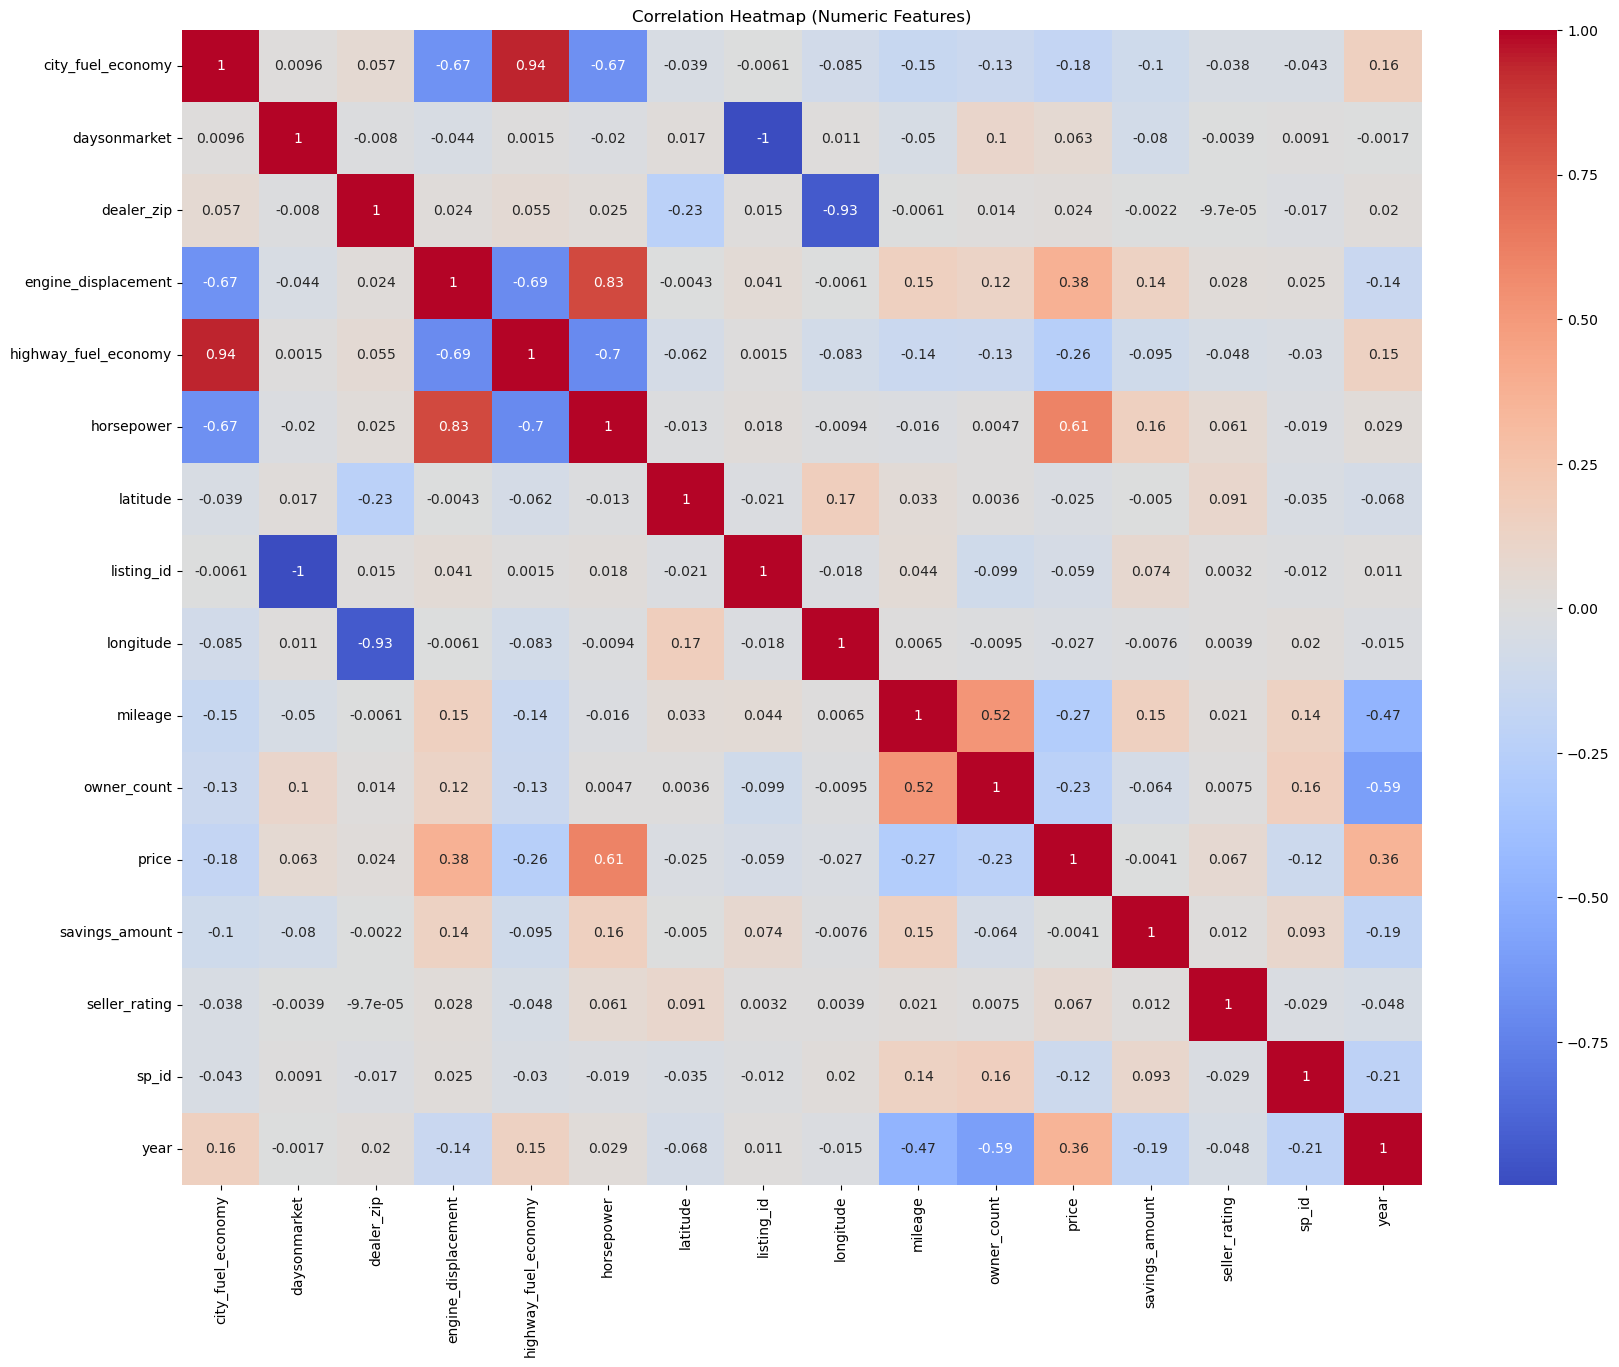

C:\Users\loihu\AppData\Local\Temp\ipykernel_20520\1902678675.py:16: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numeric_cols = df.select(pl.col(pl.NUMERIC_DTYPES)).columns


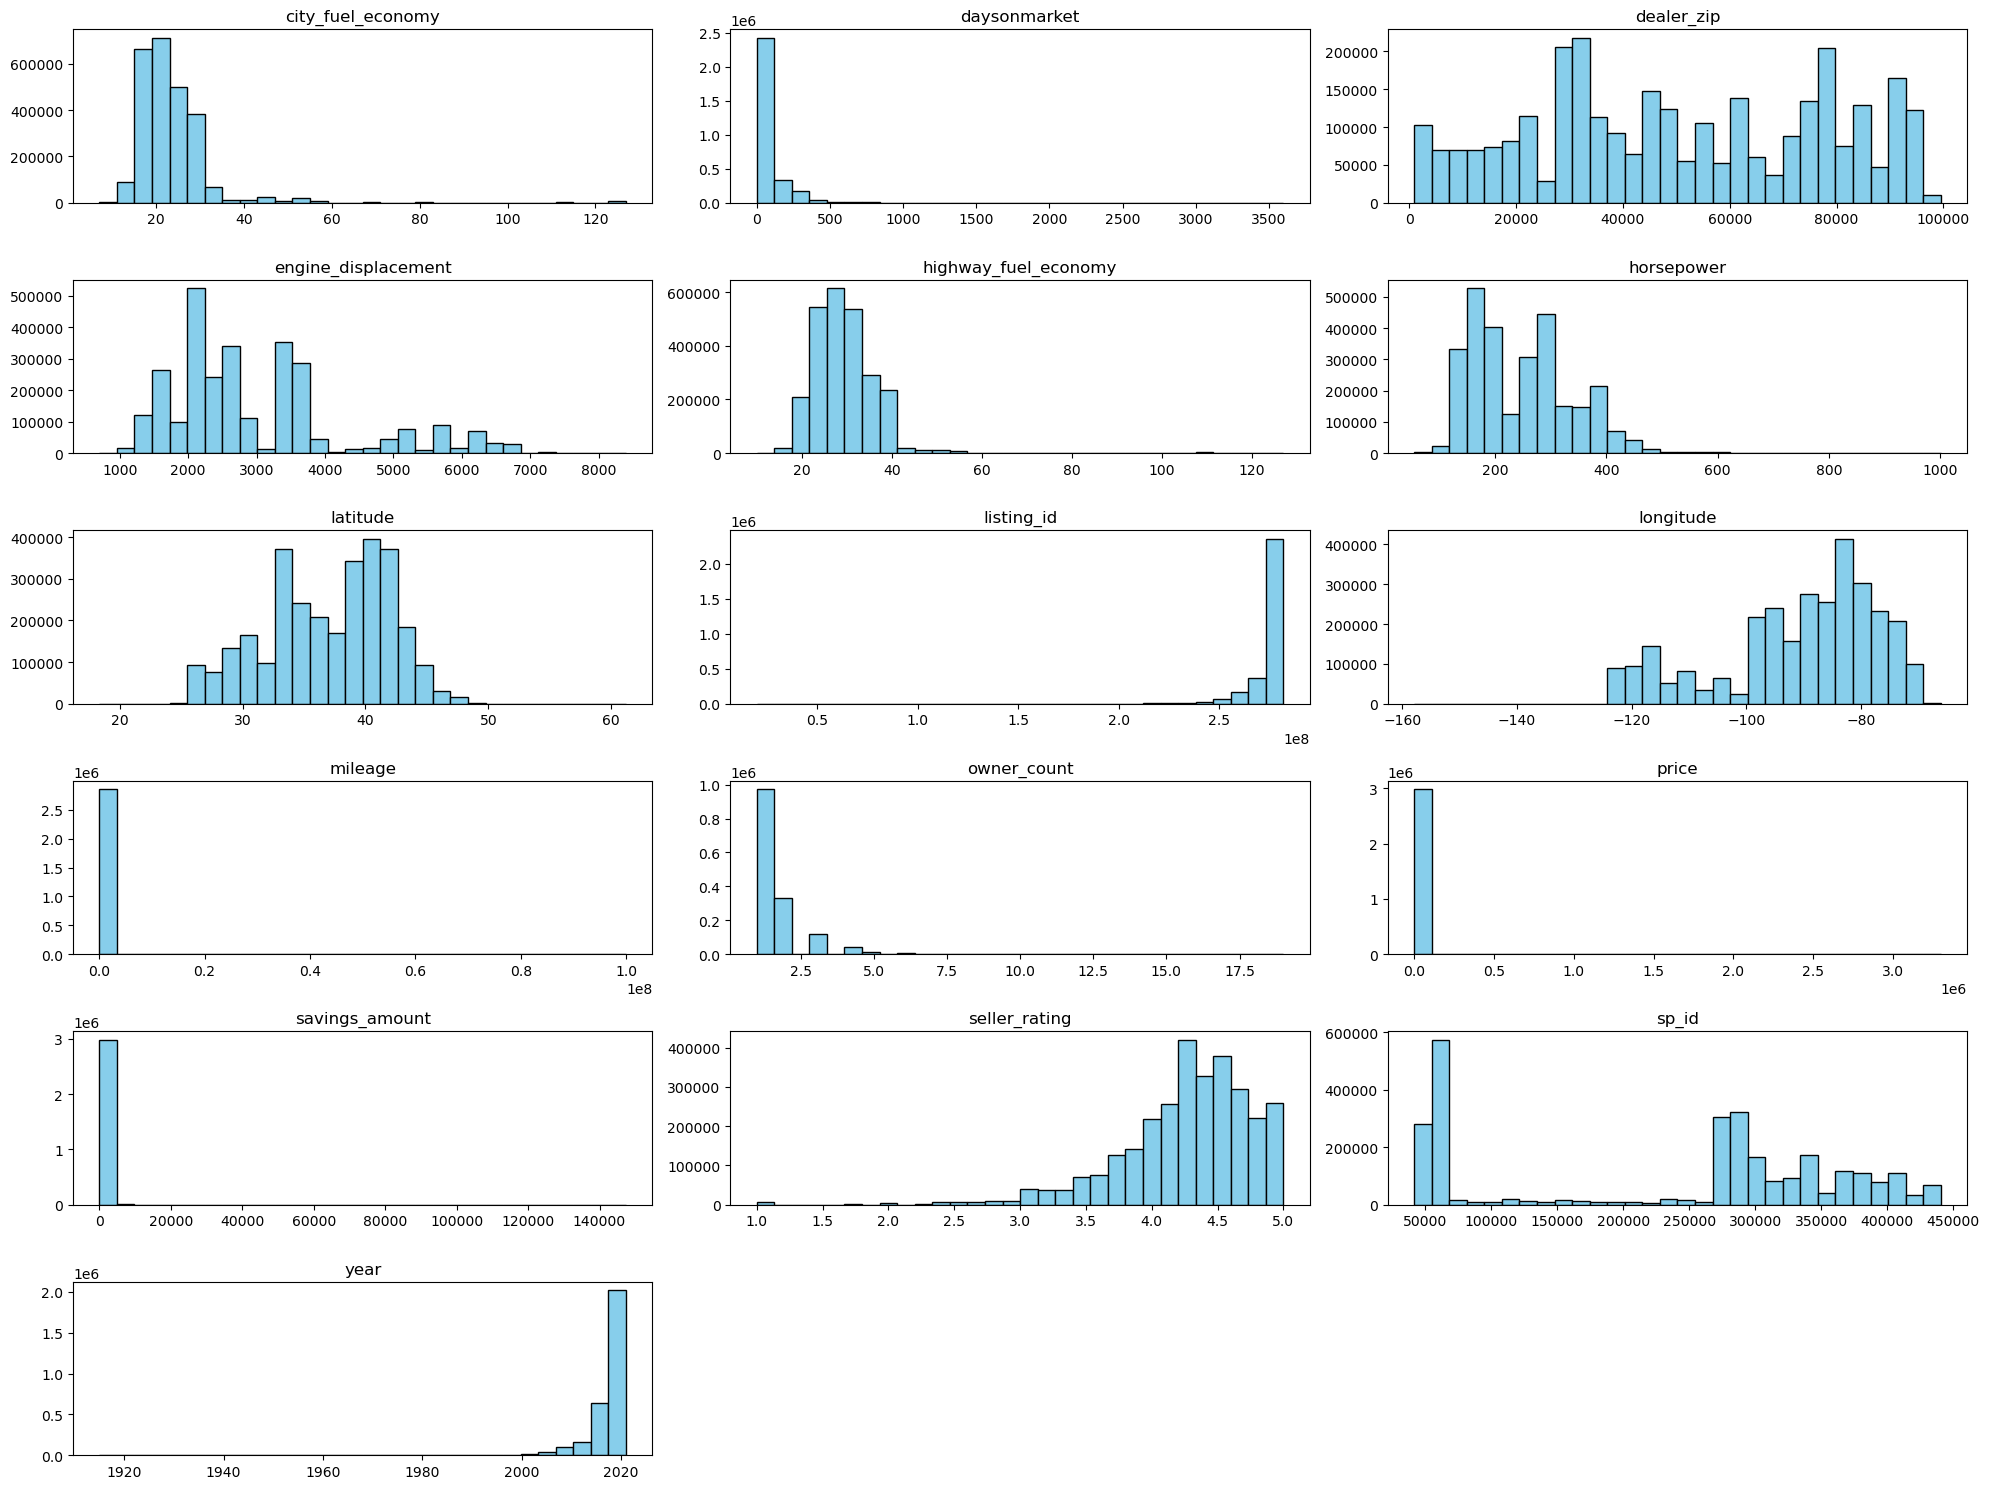

In [3]:
# Stage 3: Visualization and Data Description Report
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix (Polars) and convert to Pandas
corr_matrix = df.select(pl.col(pl.NUMERIC_DTYPES)).to_pandas().corr()

# Correlation heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# General histogram visualization
# Select numeric columns
numeric_cols = df.select(pl.col(pl.NUMERIC_DTYPES)).columns

# Plot histograms for each numeric column
plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols)//3 + 1, 3, i)  # 3 plots per row
    plt.hist(df[col].to_numpy(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.tight_layout()

plt.show()


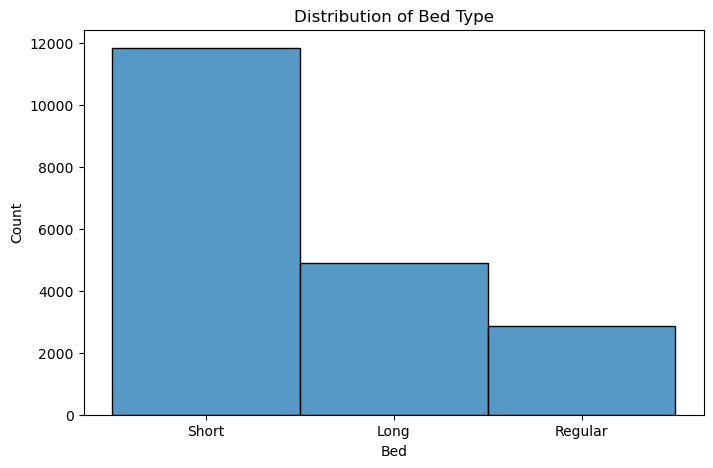

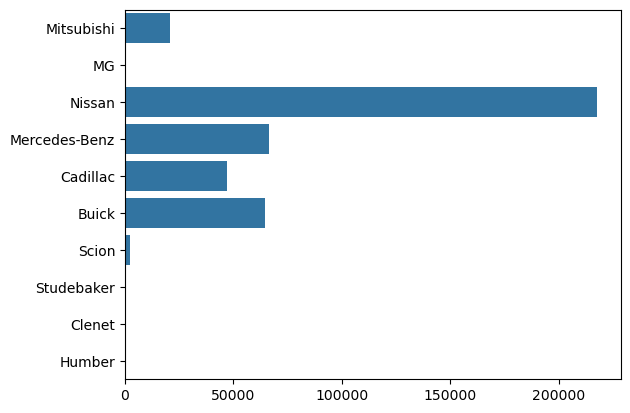

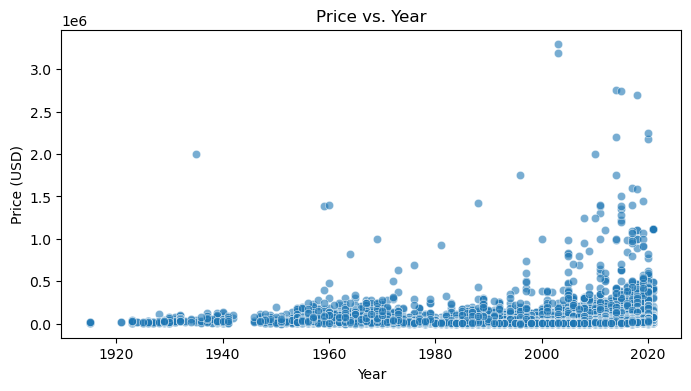

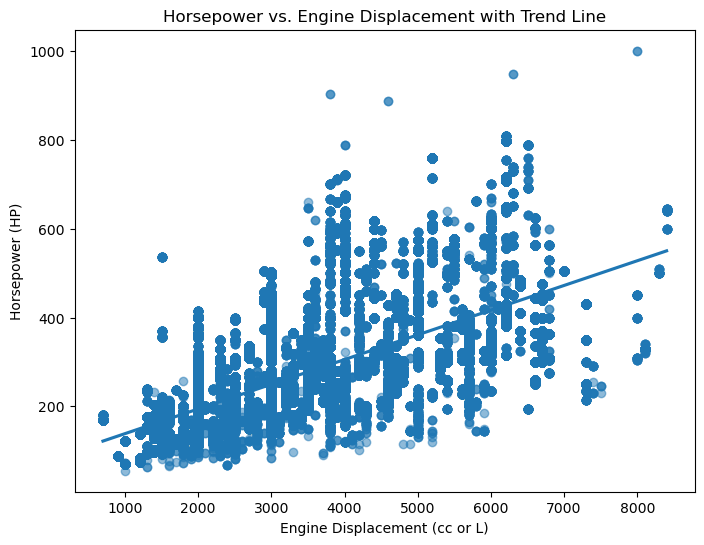

In [11]:
# 1. Price distribution (Bed Type)

plt.figure(figsize=(8,5))
sns.histplot(df['bed'].to_list(), bins=50)  # convert to list for seaborn
plt.title("Distribution of Bed Type")
plt.xlabel("Bed")
plt.show()

# 2. Top 10 most common car brands

top_makes = df['make_name'].value_counts().head(10)
top_makes.columns = ['make_name', 'count'] 

sns.barplot(
    x=top_makes['count'].to_list(),
    y=top_makes['make_name'].to_list()
)


# 3. Comparison of Price and Year

plt.figure(figsize=(8,4))
sns.scatterplot(x=df['year'].to_list(), y=df['price'].to_list(), alpha=0.6)
plt.title("Price vs. Year")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()

# 4. Horsepower vs. Engine Displacement

df_clean = df.select([
    pl.col('engine_displacement').cast(pl.Float64),
    pl.col('horsepower').cast(pl.Float64)
]).drop_nulls()

plt.figure(figsize=(8,6))
sns.regplot(
    x=df_clean['engine_displacement'].to_list(),
    y=df_clean['horsepower'].to_list(),
    scatter_kws={'alpha':0.5}
)
plt.title('Horsepower vs. Engine Displacement with Trend Line')
plt.xlabel('Engine Displacement (cc or L)')
plt.ylabel('Horsepower (HP)')
plt.show()

### What data formats are used?

* Format: CSV file (.csv)

* Data Types: Mix of int, float, object (string), and datetime (needs conversion)

* Rows: 3 millions rows

* Columns: ~66 columns (numeric and categorical)

### What kind of visualization tools 

* Matplotlib, and Seaborn for standard visualizations

* Plotly for interactive dashboards

* Pandas and Polars for loading data and assist to export EDA reports

*Example plots to produce:*

- price distribution by make_name, year, or fuel_type

- daysonmarket vs. price

- Correlation between horsepower, engine_displacement, and price

- Heatmap of average price by state

- Time trend of listings using listed_date

### How can data be grouped?

| Grouping Level                                                               | Example Use Case                                         | Benefit                                                |
| :--------------------------------------------------------------------------- | :------------------------------------------------------- | :----------------------------------------------------- |
| **Manufacturer / Make (`make_name`)**                                        | Compare price ranges across brands (e.g., Toyota vs BMW) | Identify which brands sell faster or at higher margins |
| **Vehicle Type (`body_type`)**                                               | Compare SUVs vs Sedans vs Trucks                         | Know which body types move faster in inventory         |
| **Fuel Type (`fuel_type`)**                                                  | Compare electric, hybrid, gas, diesel                    | Study eco-trend impacts on resale price                |
| **Transmission (`transmission`)**                                            | Manual vs Automatic                                      | Check buyer preferences                                |
| **Geographic Location `city`, `dealer_zip`)**                      | Price variations across US regions                       | Regional pricing optimization                          |
| **Condition or Damage Status (`has_accidents`, `frame_damaged`, `salvage`)** | Evaluate how damage history affects sale time            | Optimize valuation models                              |
| **Year and Mileage (`year`, `mileage`)**                                     | Depreciation analysis                                    | Model car age vs resale price                          |
| **Dealer (`sp_id`, `sp_name`)**                                              | Performance of franchise vs independent dealers          | Business insights for partnerships                     |
 

### Try to find out any other necessary data sources

| External Source                                                   | Type of Data                               | How It Adds Value                                 | Join Key / Connection                        |
| :---------------------------------------------------------------- | :----------------------------------------- | :------------------------------------------------ | :------------------------------------------- |
| **US Fuel Prices (U.S. Energy Information Administration – EIA)** | Average gas prices per state/month         | Compare how fuel cost affects used-car demand     | Join by `city` and `listed_date` month/year |
| **US Census / BEA Data**                                          | Median income, population per state/county | Economic conditions affecting car prices          | Join by `city` or `dealer_zip`              |
| **Google Trends API**                                             | Search popularity for car brands           | Measure brand interest and correlate with pricing | Match by `make_name` and time                |
| **Vehicle Recall Database (NHTSA)**                               | Recall history per VIN                     | Adds quality/risk information                     | Match by `vin`                               |
| **Interest Rate Data (Federal Reserve)**                          | Loan/financing rates                       | Correlate with demand fluctuations                | Join by `listed_date` (month/year)           |



Data Description Report:
Dataset shape: (3000040, 66)
Columns: ['vin', 'back_legroom', 'bed', 'bed_height', 'bed_length', 'body_type', 'cabin', 'city', 'city_fuel_economy', 'combine_fuel_economy', 'daysonmarket', 'dealer_zip', 'description', 'engine_cylinders', 'engine_displacement', 'engine_type', 'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'has_accidents', 'height', 'highway_fuel_economy', 'horsepower', 'interior_color', 'isCab', 'is_certified', 'is_cpo', 'is_new', 'is_oemcpo', 'latitude', 'length', 'listed_date', 'listing_color', 'listing_id', 'longitude', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count', 'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'sp_name', 'theft_title', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'vehicle_damage_category', 'wheel_system', 'wheel_system_display'

C:\Users\loihu\AppData\Local\Temp\ipykernel_20520\2046557077.py:40: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  corr_matrix = df.select(pl.col(pl.NUMERIC_DTYPES)).to_pandas().corr()


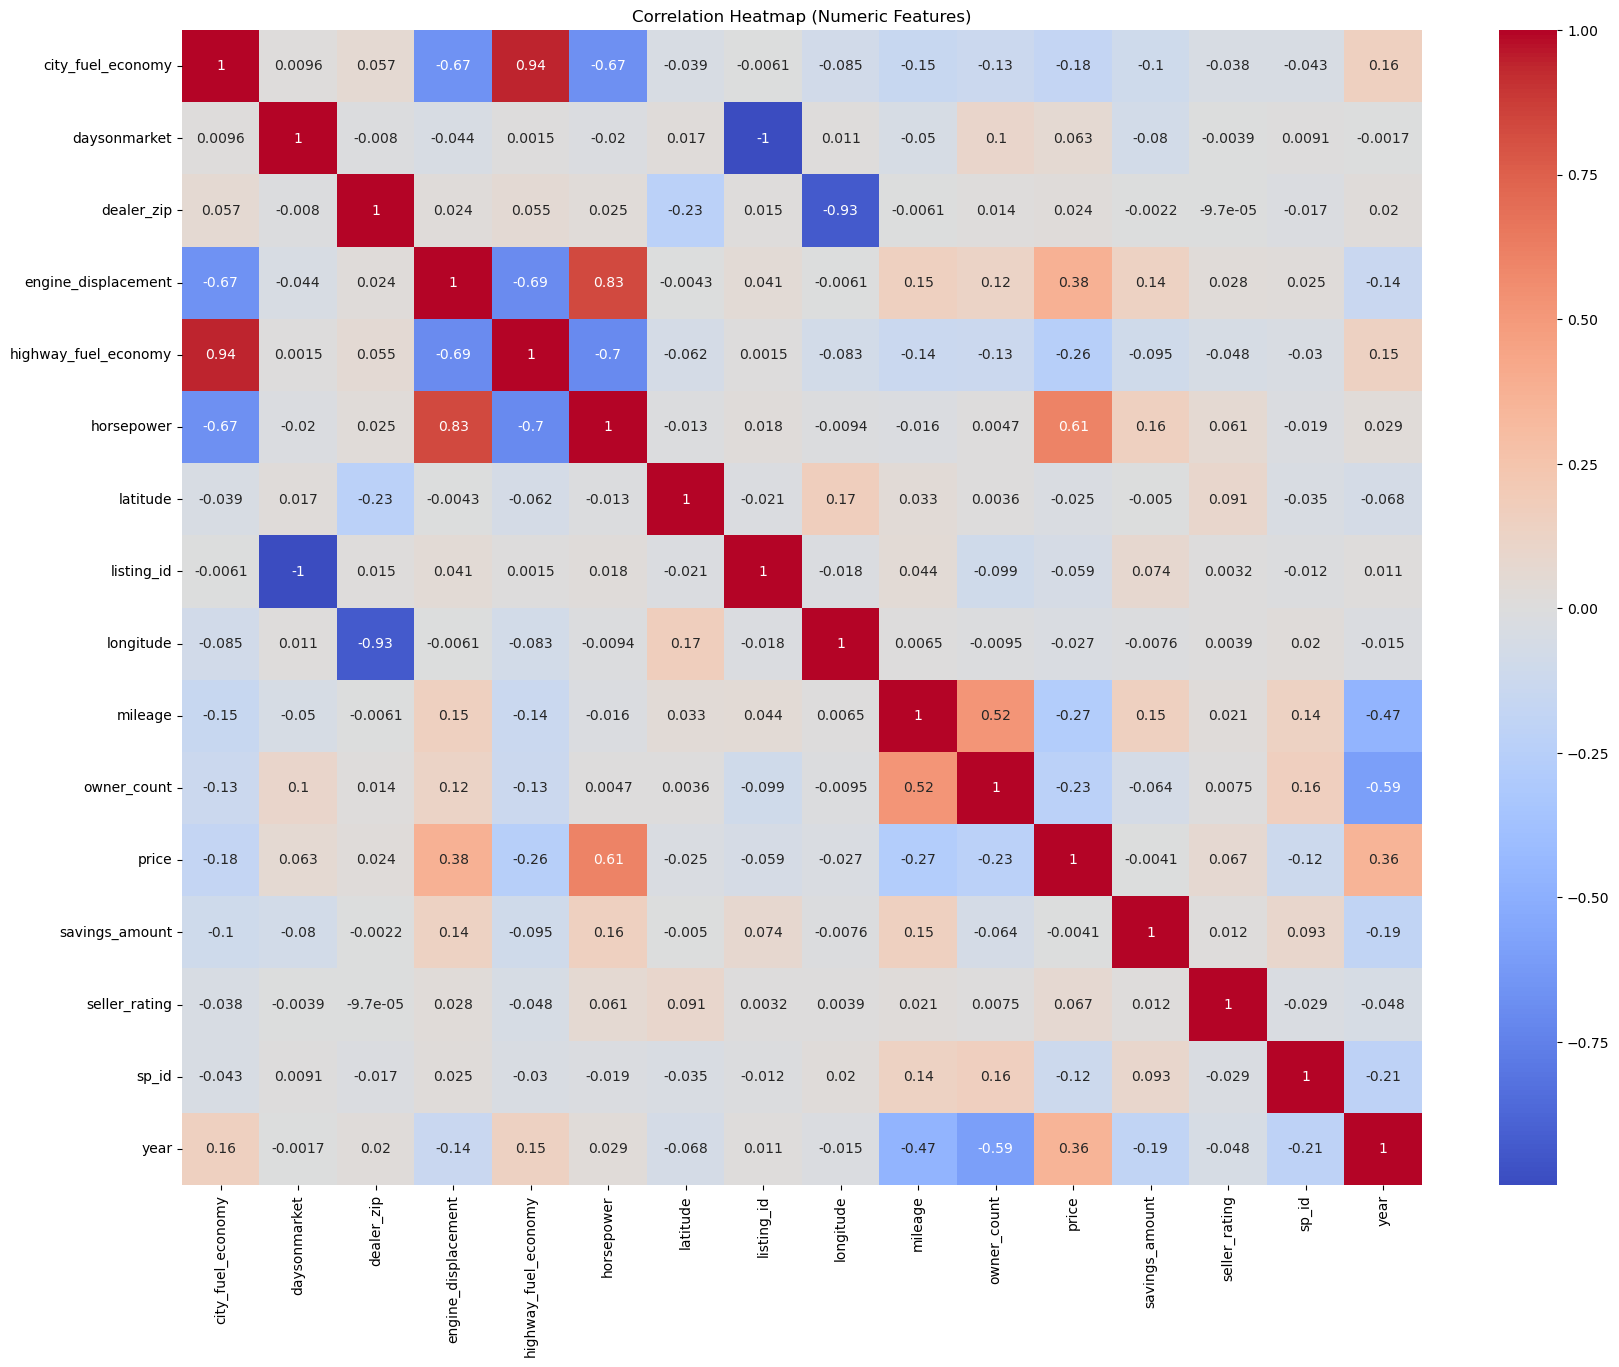

In [12]:
print('Data Description Report:')

# Column info
print("Dataset shape:", df.shape)

print(f"Columns: {df.columns}")

print("\nInfo:")
print(f"Dtypes: {df.schema}")

# Duplicate rows
total_rows = df.height  # total number of rows
unique_rows = df.unique().height  # unique rows
num_duplicates = total_rows - unique_rows

print("Number of duplicate rows:", num_duplicates)

# Missing values
missing_values = df.null_count()
print("Missing values per column:")
print(missing_values)

# Missing percentage
missing_percent = (df.null_count() / df.height * 100)
print("Missing value percentage per column:")
print(missing_percent)

# Unique values
unique_values = df.select([pl.col(col).n_unique().alias(col) for col in df.columns])
print("Number of unique values per column:")
print(unique_values)

# Descriptive stats
print("\n=== Descriptive Statistics ===")
print(df.describe())

# Correlation (numerical)
print("\n=== Correlation Matrix ===")
# Compute correlation matrix (Polars) and convert to Pandas
corr_matrix = df.select(pl.col(pl.NUMERIC_DTYPES)).to_pandas().corr()

# Correlation heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()